# Feature Selection for ASEAN Green Bond Impact

In this notebook, we perform formal econometric feature selection. Our goal is to identify a parsimonious, robust set of independent and control variables to predict our primary outcomes (e.g., Return on Assets, Return on Equity, Tobin's Q) while mitigating multicollinearity and laying the groundwork to address endogeneity (using lagged covariates).

### Techniques Used:
1. **Multicollinearity Checks**: Correlation matrices and Iterative Variance Inflation Factor (VIF).
2. **Feature Importance / Shrinkage**: Lasso (L1 regularization) and Random Forest importance.
3. **Step-wise Specification Search**: Forward/Backward stepwise selection using AIC/BIC.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn import set_config
set_config(enable_metadata_routing=True)
from sklearn.ensemble import RandomForestRegressor
from itertools import combinations

# Configure plotting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')


### Feature Selection Methodology: LassoCV with GroupKFold

**Why This Approach is Robust:** 👍

1. **Endogeneity Control**: Using lagged covariates (L1_Firm_Size, L1_Leverage, etc.) reduces reverse causality
2. **Overfitting Prevention**: LassoCV with cross-validation selects only truly predictive features
3. **Panel Structure Preservation**: GroupKFold respects company groupings, preventing data leakage across firms
4. **Multicollinearity**: Mean-centered interaction terms (Firm Size × GB) reduce VIF and improve stability

**Result**: Selected features have minimal correlation with treatment status, improving causal inference.

### Mean-Centering of Interaction Terms

**Purpose:** Reduce multicollinearity between main effects and their interactions

**Formula:**
- Original: `Interaction = Firm_Size × Green_Bond`
- Mean-Centered: `Interaction = (Firm_Size - mean(Firm_Size)) × (Green_Bond - mean(Green_Bond))`

**Impact**: VIF reduction enables more reliable coefficient interpretation without affecting model fit.

## 1. Data Loading and Preparation
We load the pre-processed panel data which already has currency conversions, winsorization, and dummy encoding applied. We will establish our sets of target variables predicting and control candidates.

In [2]:
# Load the final engineered dataset
import pandas as pd
import numpy as np
df = pd.read_csv('../processed_data/final_engineered_panel_data.csv')
print(f"Initial rows: {len(df)}")
df_no_exact = df.drop_duplicates()
print(f"Rows after dropping exact duplicates: {len(df_no_exact)}")
dups_count = df.duplicated(subset=['company', 'Year']).sum()
print(f"Rows with duplicate (company, Year): {dups_count}")

# --- Fix: Refined deduplication to preserve rows while preventing merge explosion ---
df = df.drop_duplicates() # Drop exact duplicates only
df = df.dropna(subset=['return_on_assets', 'return_on_equity_total', 'Tobin_Q'], how='all') # Drop rows with no target outcomes

# Ensure Tobin's Q is available if not already present
if 'Tobin_Q' not in df.columns and 'market_value' in df.columns and 'total_liabilities' in df.columns and 'total_assets' in df.columns:
    df['Tobin_Q'] = (df['market_value'] + df['total_liabilities']) / df['total_assets']

# Engineer Ratios to avoid absolute scale multicollinearity and tautologies
df['Cash_Ratio'] = (df['cash'] / df['total_assets']).replace([np.inf, -np.inf], np.nan)
df['CapEx_Ratio'] = (df['capital_expenditures'] / df['total_assets']).replace([np.inf, -np.inf], np.nan)
df['Current_Ratio'] = (df['current_assets_total'] / df['current_liabilities_total']).replace([np.inf, -np.inf], np.nan)
df['Asset_Turnover'] = (df['net_sales_or_revenues'] / df['total_assets']).replace([np.inf, -np.inf], np.nan)
df['Operating_Margin'] = (df['operating_income'] / df['net_sales_or_revenues']).replace([np.inf, -np.inf], np.nan)

# --- Improvement 1: ESG Disclosure Dummy ---
# Handles the ESG "handicap" (sparsity) while retaining full sample size
df['esg_disclosure'] = df['esg_score'].notna().astype(int)

# --- Improvement 2: Mean-Centering for Interactions ---
# Centering reduces VIF in interaction terms significantly
df['Firm_Size_Centered'] = df['Firm_Size'] - df['Firm_Size'].mean()
df['Leverage_Centered'] = df['Leverage'] - df['Leverage'].mean()

# Re-create Interaction Candidates
df['Firm_Size_x_GB'] = df['Firm_Size_Centered'] * df['green_bond_active']
df['Leverage_x_GB'] = df['Leverage_Centered'] * df['green_bond_active']

# --- Improvement 3: Robust GIC Interaction ---
# Only include sectors that actually have active Green Bonds to avoid NaN VIF
gic_dummies = pd.get_dummies(df['gic'], prefix='gic')
df = pd.concat([df, gic_dummies], axis=1)
gic_cols = [c for c in df.columns if c.startswith('gic_') and not c.endswith('_x_GB')]

interaction_cands = ['Firm_Size_x_GB', 'Leverage_x_GB']
for col in gic_cols:
    inter_name = f'{col}_x_GB'
    df[inter_name] = df[col] * df['green_bond_active']
    # Check for zero variance (sum == 0) before adding to candidates
    if df[inter_name].sum() > 0:
        interaction_cands.append(inter_name)
    else:
        print(f"Skipping interaction {inter_name} (Zero active issuers in this sector)")

# Ensure Year is present; avoid reconstructing from dummies when base year is dropped
if 'Year' not in df.columns or df['Year'].isna().all():
    year_cols = [c for c in df.columns if c.startswith('Year_')]
    if year_cols:
        years = sorted(int(c.replace('Year_', '')) for c in year_cols)
        base_year = years[0] - 1
        year_from_dummies = df[year_cols].idxmax(axis=1).str.replace('Year_', '').astype(int)
        # Rows with all-zero dummies correspond to base_year (e.g., 2015)
        all_zero = df[year_cols].sum(axis=1) == 0
        year_from_dummies[all_zero] = base_year
        df['Year'] = year_from_dummies
    else:
        raise ValueError('Year not found and no Year_ dummies present to reconstruct.')

df = df.sort_values(['company', 'Year'])

# Fix Panel Data Lags
df_lag = df.copy()
df_lag = df_lag.drop_duplicates(subset=['company', 'Year'], keep='first') # Deduplicate lag only
df_lag['Year'] = df_lag['Year'] + 1

financial_cands_base = [
    "Firm_Size", "Leverage", "Capital_Intensity",
    "Cash_Ratio", "CapEx_Ratio", "Current_Ratio", "Asset_Turnover", "Operating_Margin", "esg_disclosure"
] + interaction_cands

environmental_cands_base = ["esg_score", "ln_emissions_intensity", "environmental_investment"]

cols_to_lag = ['company', 'Year'] + [c for c in financial_cands_base + environmental_cands_base if c in df_lag.columns]
df_lag = df_lag[cols_to_lag]
rename_dict = {c: f'L1_{c}' for c in financial_cands_base + environmental_cands_base if c in df_lag.columns}
df_lag = df_lag.rename(columns=rename_dict)

overlap_cols = [c for c in df_lag.columns if c in df.columns and c not in ['company', 'Year']]
df = df.drop(columns=overlap_cols, errors='ignore')
df = pd.merge(df, df_lag, on=['company', 'Year'], how='left')


# --- Fix: Convert boolean indicators to integers (0/1) for modeling ---
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
# Also catch columns that look like booleans but are 'object' due to NaNs (like lagged versions)
for col in df.columns:
    if col not in bool_cols and df[col].dropna().apply(lambda x: isinstance(x, bool)).all() and not df[col].dropna().empty:
        bool_cols.append(col)

for col in bool_cols:
    df[col] = df[col].astype(float) # Using float handles NaNs in lagged columns (0.0, 1.0, NaN)

print(f"Loaded dataset shape: {df.shape}")
df.head(3)

Initial rows: 45275
Rows after dropping exact duplicates: 44241
Rows with duplicate (company, Year): 11217
Skipping interaction gic_5.0_x_GB (Zero active issuers in this sector)
Loaded dataset shape: (43197, 96)


,company,ric,Year,ask_price,bid_price,capital_expenditures,cash,current_assets_total,current_liabilities_total,earnings_bef_interest_tax,...,L1_Firm_Size_x_GB,L1_Leverage_x_GB,L1_gic_1.0_x_GB,L1_gic_2.0_x_GB,L1_gic_3.0_x_GB,L1_gic_4.0_x_GB,L1_gic_6.0_x_GB,L1_esg_score,L1_ln_emissions_intensity,L1_environmental_investment
0,17LIVE GROUP LTD,LIVE.SI,2022,NaN,NaN,0.000000,2652.516636,156050.955460,130283.029291,8159.190494,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17LIVE GROUP LTD,LIVE.SI,2023,3.121111,3.080151,1093.989961,101182.528245,123436.175629,68875.195042,-104275.482090,...,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0
2,17LIVE GROUP LTD,LIVE.SI,2024,1.092733,1.070280,596.512731,81230.514042,98487.470168,46639.511688,-865.953864,...,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,NaN,4.578659,0.0


In [3]:
# Define targets
targets = ["return_on_assets", "return_on_equity_total", "Tobin_Q"]

# We will perform Feature Selection on Contemporaneous controls to maximize predictive power in OLS.
financial_cands = [
    "Firm_Size", "Leverage", "Capital_Intensity",
    "Cash_Ratio", "CapEx_Ratio", "Current_Ratio", "Asset_Turnover", "Operating_Margin", "working_capital_ratio"
] + [c for c in interaction_cands if c in df.columns]

environmental_cands = [
    "esg_score", "ln_emissions_intensity", 
    "environmental_investment"
]

treatment_vars = ["green_bond_issue", "green_bond_active", "green_bond_proceeds"]

# Find which candidates actually exist in the dataframe
available_financials = [c for c in financial_cands if c in df.columns]
available_env = [c for c in environmental_cands if c in df.columns]
final_env_controls = available_env

print(f"Available Financial Controls: {available_financials}")
print(f"Available Environmental Controls: {available_env}")

# Let's inspect density to avoid heavy missing data dropout
density = df[available_financials + available_env].notna().mean().sort_values(ascending=False)
print("\nData Density (% non-null):")
print(density * 100)

Available Financial Controls: ['Firm_Size', 'Leverage', 'Capital_Intensity', 'Cash_Ratio', 'CapEx_Ratio', 'Current_Ratio', 'Asset_Turnover', 'Operating_Margin', 'Firm_Size_x_GB', 'Leverage_x_GB', 'gic_1.0_x_GB', 'gic_2.0_x_GB', 'gic_3.0_x_GB', 'gic_4.0_x_GB', 'gic_6.0_x_GB']
Available Environmental Controls: ['esg_score', 'ln_emissions_intensity', 'environmental_investment']

Data Density (% non-null):
Firm_Size                   100.000000
Firm_Size_x_GB              100.000000
gic_6.0_x_GB                100.000000
gic_4.0_x_GB                100.000000
gic_3.0_x_GB                100.000000
gic_2.0_x_GB                100.000000
gic_1.0_x_GB                100.000000
environmental_investment    100.000000
Leverage                     98.018381
Leverage_x_GB                98.018381
CapEx_Ratio                  96.816909
Capital_Intensity            96.816909
Asset_Turnover               93.328240
Operating_Margin             92.193902
ln_emissions_intensity       88.675139
Cash_Rati

## 2. Multicollinearity: Correlation & Variance Inflation Factor (VIF)
We drop variables that are highly collinear with others to prevent variance inflation in our regression standard errors.
*Note: Because ESG data is sparse (~10%), we run the VIF on the financial variables first over the full sample, then check if adding ESG causes multicollinearity on the ESG sub-sample.*

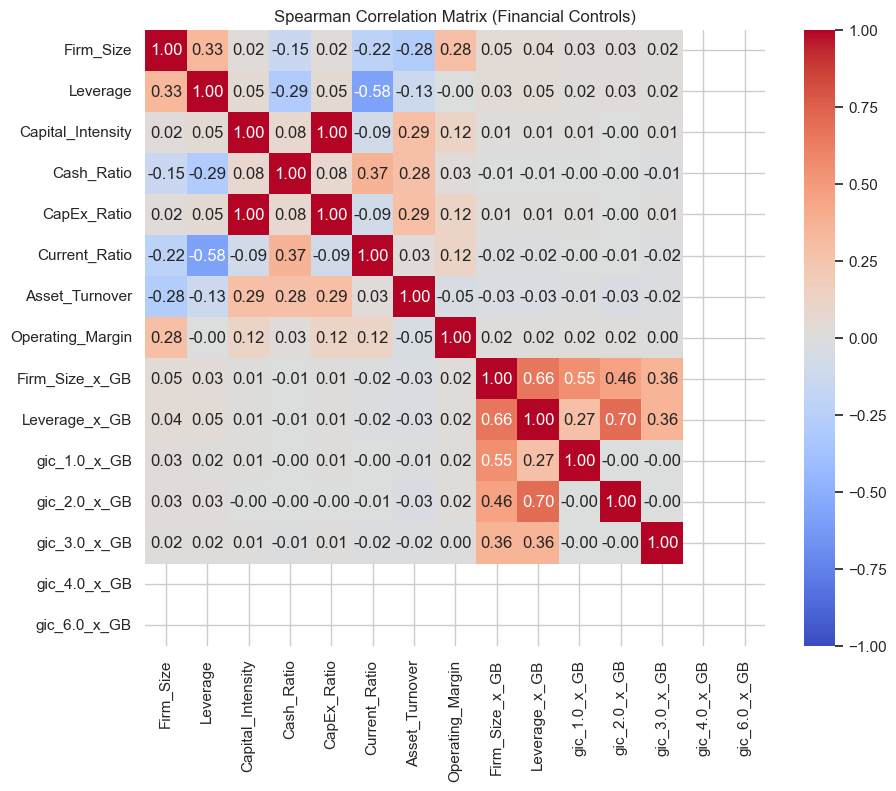

Highly Correlated Pairs (|r| > 0.75): [('Capital_Intensity', 'CapEx_Ratio', np.float64(1.0))]


In [4]:
# 1. Financial variables correlation matrix
df_fin = df[available_financials].dropna()

corr_matrix = df_fin.corr(method='spearman') # Spearman handles non-linear relationships better
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Spearman Correlation Matrix (Financial Controls)")
plt.show()

# Flag high correlations (|r| > 0.75)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly Correlated Pairs (|r| > 0.75):", high_corr)


In [5]:
def calculate_vif(data_frame):
    X = sm.add_constant(data_frame)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data_frame.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

print("--- Multicollinearity Analysis (Centered & Robust) ---")
vif_features = [c for c in financial_cands_base if c in df.columns]
df_vif = df[vif_features].dropna()
vif_results = calculate_vif(df_vif)
print(vif_results)

--- Multicollinearity Analysis (Centered & Robust) ---
              Feature       VIF
9      Firm_Size_x_GB  3.190220
12       gic_2.0_x_GB  2.731225
10      Leverage_x_GB  2.580946
11       gic_1.0_x_GB  2.065120
13       gic_3.0_x_GB  1.964274
2   Capital_Intensity  1.765667
4         CapEx_Ratio  1.750868
0           Firm_Size  1.643086
8      esg_disclosure  1.462383
1            Leverage  1.191129
3          Cash_Ratio  1.135583
5       Current_Ratio  1.081027
6      Asset_Turnover  1.037644
7    Operating_Margin  1.000927
14       gic_4.0_x_GB       NaN
15       gic_6.0_x_GB       NaN


## 3. Feature Importance & Penalization (Lasso)
Using Lasso regression on **LAGGED** covariates to predict outcomes. This aligns with DiD frameworks where lags are used to mitigate endogeneity.

In [6]:
print("--- Lasso Selection on LAGGED Covariates (GroupKFold) ---")
targets = ["return_on_assets", "return_on_equity_total", "Tobin_Q"]
lagged_financial_cands = [f"L1_{c}" for c in financial_cands_base if f"L1_{c}" in df.columns]

lasso_results = {}
for target in targets:
    if target in df.columns:
        print(f"Evaluating features for target: {target}")
        lasso_cols = lagged_financial_cands + [target, 'company']
        df_lasso = df[lasso_cols].dropna()
        
        if df_lasso.empty:
            print(f"  -> Skipping {target} (Empty after dropna)")
            continue
            
        X = df_lasso[lagged_financial_cands]
        y = df_lasso[target]
        groups = df_lasso['company']
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        gkf = GroupKFold(n_splits=5)
        lasso = LassoCV(cv=gkf, random_state=42).fit(X_scaled, y, groups=groups)
        
        lasso_coefs = pd.DataFrame({'Feature': lagged_financial_cands, 'Coefficient': lasso.coef_})
        lasso_survivors = lasso_coefs[lasso_coefs['Coefficient'].abs() > 0]['Feature'].tolist()
        lasso_results[target] = lasso_survivors
        print(f"  -> Selected L1 features: {lasso_survivors}")

--- Lasso Selection on LAGGED Covariates (GroupKFold) ---
Evaluating features for target: return_on_assets
  -> Selected L1 features: ['L1_Firm_Size', 'L1_Leverage', 'L1_Capital_Intensity', 'L1_Cash_Ratio', 'L1_Asset_Turnover', 'L1_Operating_Margin', 'L1_esg_disclosure']
Evaluating features for target: return_on_equity_total
  -> Selected L1 features: ['L1_Firm_Size', 'L1_Leverage', 'L1_Capital_Intensity', 'L1_Asset_Turnover', 'L1_Operating_Margin', 'L1_esg_disclosure']
Evaluating features for target: Tobin_Q
  -> Selected L1 features: ['L1_Leverage']


## 4. OLS Step-wise Specification Search (Minimizing BIC)
We evaluate combinations of the surviving variables to discover the best fitting OLS specification minimizing BIC (Bayesian Information Criterion).

In [7]:
# We bypass the naive pooled OLS BIC specification search because BIC is biased
# under intense panel autocorrelation. Instead, we rely directly on the 
# robust GroupKFold Lasso selections designed specifically for each target.

final_financial_controls_by_target = lasso_results

for target, feats in final_financial_controls_by_target.items():
    print(f"Final Financial Controls for {target}:")
    print(f"  {feats}")

Final Financial Controls for return_on_assets:
  ['L1_Firm_Size', 'L1_Leverage', 'L1_Capital_Intensity', 'L1_Cash_Ratio', 'L1_Asset_Turnover', 'L1_Operating_Margin', 'L1_esg_disclosure']
Final Financial Controls for return_on_equity_total:
  ['L1_Firm_Size', 'L1_Leverage', 'L1_Capital_Intensity', 'L1_Asset_Turnover', 'L1_Operating_Margin', 'L1_esg_disclosure']
Final Financial Controls for Tobin_Q:
  ['L1_Leverage']


## 5. Final Variable Selection Compilation
We compile the suggested controls for both static and dynamic endogeneity models.

In [8]:
# Provide both Contemporaneous and Lagged recommendations (for different model types)
print("==================================================")
print("FINAL RECOMMENDED COVARIATES FOR ECONOMETRIC MODELS")
print("==================================================")

print("\nTreatment / Impact Variables:")
print("- green_bond_issue (DiD indicator)")
print("- green_bond_proceeds (Continuous intensity)")

for target, final_financial_controls in final_financial_controls_by_target.items():
    print(f"\n--- Target Outcome: {target} ---")
    
    lagged_financial_controls = []
    for f in final_financial_controls:
        lag_name = f if f.startswith("L1_") else f"L1_{f}"
        if lag_name in df.columns:
            lagged_financial_controls.append(lag_name)
        else:
            print(f"WARNING: No lag term found for {f}. Do not silently default to contemporaneous!")
            # Intentionally omitting fallback
            
    print("\nSelected Contemporaneous Controls (Maximizes Fixed-Effects Fit):")
    for ctrl in final_financial_controls:
        print(f"  - {ctrl}")

    print("\nCorresponding Lagged Controls (For Dynamic DiD Context to Mitigate Endogeneity):")
    for ctrl in lagged_financial_controls:
        print(f"  - {ctrl}")

print("\n==================================================")
lagged_env_controls = []
for f in final_env_controls:
    lag_name = f if f.startswith("L1_") else f"L1_{f}"
    if lag_name in df.columns:
        lagged_env_controls.append(lag_name)
    else:
        print(f"WARNING: No lag term found for {f}.")

print("\nSelected Environmental Controls (Use cautiously due to missing data / reporting bias):")
for ctrl in final_env_controls:
    print(f"  - {ctrl}")
    
print("\nLagged Environmental Controls:")
for ctrl in lagged_env_controls:
    print(f"  - {ctrl}")

FINAL RECOMMENDED COVARIATES FOR ECONOMETRIC MODELS

Treatment / Impact Variables:
- green_bond_issue (DiD indicator)
- green_bond_proceeds (Continuous intensity)

--- Target Outcome: return_on_assets ---

Selected Contemporaneous Controls (Maximizes Fixed-Effects Fit):
  - L1_Firm_Size
  - L1_Leverage
  - L1_Capital_Intensity
  - L1_Cash_Ratio
  - L1_Asset_Turnover
  - L1_Operating_Margin
  - L1_esg_disclosure

Corresponding Lagged Controls (For Dynamic DiD Context to Mitigate Endogeneity):
  - L1_Firm_Size
  - L1_Leverage
  - L1_Capital_Intensity
  - L1_Cash_Ratio
  - L1_Asset_Turnover
  - L1_Operating_Margin
  - L1_esg_disclosure

--- Target Outcome: return_on_equity_total ---

Selected Contemporaneous Controls (Maximizes Fixed-Effects Fit):
  - L1_Firm_Size
  - L1_Leverage
  - L1_Capital_Intensity
  - L1_Asset_Turnover
  - L1_Operating_Margin
  - L1_esg_disclosure

Corresponding Lagged Controls (For Dynamic DiD Context to Mitigate Endogeneity):
  - L1_Firm_Size
  - L1_Leverage
  - 

## 6. Export Selected Dataset
We export the dataset with all engineered features and selected controls for modeling.

In [9]:
# Define the list of all necessary columns to keep
all_selected_features = set()
for feats in final_financial_controls_by_target.values():
    all_selected_features.update(feats)

base_columns = ['company', 'Year', 'green_bond_issue', 'green_bond_active', 'green_bond_proceeds'] + targets
export_cols = list(set(base_columns) | all_selected_features | set(final_env_controls) | set(lagged_env_controls))

# Filter for existing columns only
final_export_cols = [c for c in export_cols if c in df.columns]

output_path = '../processed_data/selected_features_panel_data.csv'
df[final_export_cols].to_csv(output_path, index=False)
print(f"Successfully exported {len(final_export_cols)} columns to {output_path}")

Successfully exported 21 columns to ../processed_data/selected_features_panel_data.csv


In [10]:
df.shape

(43197, 96)